# Terzaghi 1D Single-Layer

Demo for the 1D single layer FEM model to get settlement.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.fem import Get_terzaghi1D_FEA
from src.plotting.terzaghi_1d.plot import Get_Settlement_Plot

sns.set_theme(style="whitegrid")

H = 5.0
num = 100
nodes = num + 1
load = 100.0
Cv = 2e-7
Mv = 5e-4
base = 2.5
T = 365 * (24 * 60 * 60)
time_steps = 1000
use_uniform_u0 = False

depth = - np.linspace(0.0, H, nodes) 
time_day = np.linspace(0.0, T / (60 * 60 * 24), time_steps)


w_w = 9.81   # kN/m³
k = Cv * Mv * w_w
print(f"Cv = {Cv:.2e} m2/s")
print(f"Mv = {Mv:.2e} m2/kN")
print(f"k  = {k:.2e} m/s ")

Cv = 2.00e-07 m2/s
Mv = 5.00e-04 m2/kN
k  = 9.81e-10 m/s 


## Settlement through time

u_hist shape:             (1000, 101)
settlement_history shape: (1000,)
Final settlement:         0.096548 m
Total Settlement:         0.150851


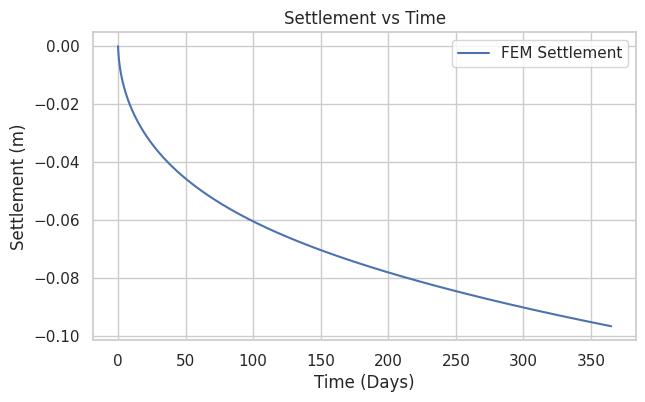

In [6]:
settlement_history, u_hist, settlement_profile = Get_terzaghi1D_FEA(H, num, load, T, time_steps, Cv, base, Mv, use_uniform_u0)

print(f"u_hist shape:             {u_hist.shape}")
print(f"settlement_history shape: {settlement_history.shape}")
print(f"Final settlement:         {settlement_history[-1]:.6f} m")
print(f"Total Settlement:         {np.sum(settlement_profile):.6f}")

fig, ax = Get_Settlement_Plot( settlement_history , time_day)

## Qaudatrue Settlement Sum

### for np.sum 

Final settlement:         0.096509 m

Total Settlement:         0.150851



### for np.trapezoid 

Final settlement:         0.097669

Total Settlement:         0.151633


## Settle3 Comparison



In [7]:
file = 'settle3_data/settle3_1d_single.xlsx'

settle3_1y = pd.read_excel(file, sheet_name='2. Stage 2 = 1 y')['Total Consolidation Settlement'].iloc[0]
settle3_1000y = pd.read_excel(file, sheet_name='3. Stage 3 = 1000 y')['Total Consolidation Settlement'].iloc[0]

results = pd.DataFrame(
    {
        'Settle3': [settle3_1y, settle3_1000y],
        'FEM Rectangle': [0.096509, 0.15851],
        'FEM Trapezoid': [0.097669, 0.151633],
    },
    index=['1 year', '1000 year']
)

results['Rectangle % Difference to Settle3'] = 100.0 * (results['FEM Rectangle'] - results['Settle3']) / results['Settle3']
results['Trapezoid % Difference to Settle3'] = 100.0 * (results['FEM Trapezoid'] - results['Settle3']) / results['Settle3']

results


,Settle3,FEM Rectangle,FEM Trapezoid,Rectangle % Difference to Settle3,Trapezoid % Difference to Settle3
1 year,0.098095,0.096509,0.097669,-1.617168,-0.434645
1000 year,0.151710,0.158510,0.151633,4.482436,-0.050564


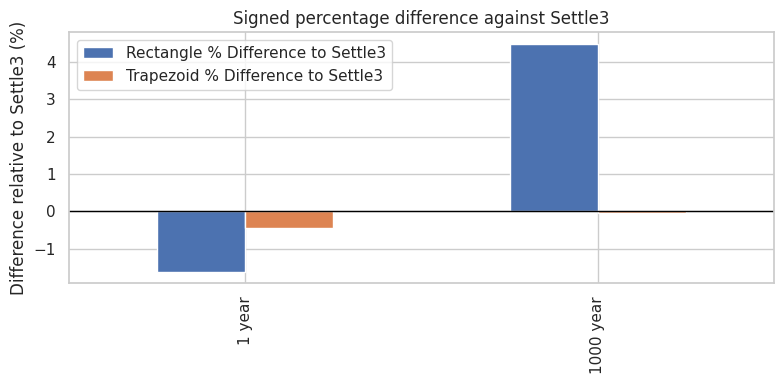

,Rectangle % Difference to Settle3,Trapezoid % Difference to Settle3
1 year,-1.617168,-0.434645
1000 year,4.482436,-0.050564


In [8]:
percent_difference = results[[
    'Rectangle % Difference to Settle3',
    'Trapezoid % Difference to Settle3',
]]

ax = percent_difference.plot(kind='bar', figsize=(8, 4))
ax.axhline(0.0, color='black', linewidth=1.0)
ax.set_ylabel('Difference relative to Settle3 (%)')
ax.set_title('Signed percentage difference against Settle3')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

percent_difference
